# Group Contributions statement

Group member:
* Yixuan Bao
* Mingyao Sun

Both two of us wrote the data acquisition, preparation and the conclusion. Yixuan led the logistic regression model, figure1, table1 and the warmup part for extra experiment. Mingyao led the support vector machine model, figure2 and table2.

Yixuan wrote the explanation of figure1, logistic regression model and adjust the overall project format. 
Mingyao wrote the explanation of figure2, support vector machine model and the group contribution statement.
We both checked each other's work and made revision to code and writing.

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [104]:
url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/refs/heads/main/inst/extdata/penguins.csv'
df = pd.read_csv(url)
df
#notice that NaN in line3

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [106]:
df.dropna(inplace=True)

# Some warmup
#model1 is just for practice because I see a very strong linear correlation between species, island, sex and bill_depth

In [109]:
def one_hot(df, cols):
    """
    df: pandas DataFrame
    param: cols a list of columns to encode 
    return a DataFrame with one-hot encoding
    """
    for each in cols:
        dummies = pd.get_dummies(df[each], prefix=each, drop_first=False)
        df = pd.concat([df, dummies], axis=1)
    return df


def label(df, cols):
    
    for each in cols:
        
        #label_encoder = LabelEncoder()
        #dummies = label_encoder.fit_transform(df[each])
        #dummies = pd.DataFrame(dummies, columns=[each])
        #df = pd.concat([df, dummies], axis=1)
        
        label_encoder = LabelEncoder()
        df[each] = label_encoder.fit_transform(df[each])
        
    return df

In [111]:
# Now we can realize that we can predict any column amazingly given all 
# the data from the other columns
def comput_test_error(X, y):
    """
    Compute test error. 
    Args:
    X: numpy array containing all features.
    y: target. A numpy array.
    Returns:
    mse: mean squared error.
    rel_se: relative squared error.
    """
    # train test split: each time you will randomly select 
    # training and test samples.
    X_train, X_test, y_train, y_test = train_test_split(X,y, 
                                                        test_size=0.2)
    
    # model initialization
    model = LinearRegression()
    # trianing this model
    model.fit(X_train, y_train)
    
    # prediction 
    y_pred = model.predict(X_test)
    # compute the test mse: mean squared error
    mse = np.sum(  (y_test - y_pred)**2  ) / np.size(y_test)
    
    # compute the relative squared error
    rel_se = np.sum(  (y_test - y_pred)**2  ) / np.sum( y_test**2 )
    
    return mse, rel_se


In [113]:
penguin_all =  ['species', 'island', 'sex']
df_cate  = one_hot(df,penguin_all)

df_cate2 = label(df, penguin_all)

In [115]:
y = df_cate['bill_length_mm'].to_numpy()
X = df_cate2.drop(columns='bill_length_mm').to_numpy()
# compute mse and relative squared errors
mse_model, rel_se_model = comput_test_error(X, y)

print(mse_model, rel_se_model)

#so amazimng, lessn than 0.01 rse, this data set is incredibly linear 
#without doubt

7.963767610109366 0.004084771580320455


In [117]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)
    
# model initialization
model = LinearRegression()
# trianing this model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

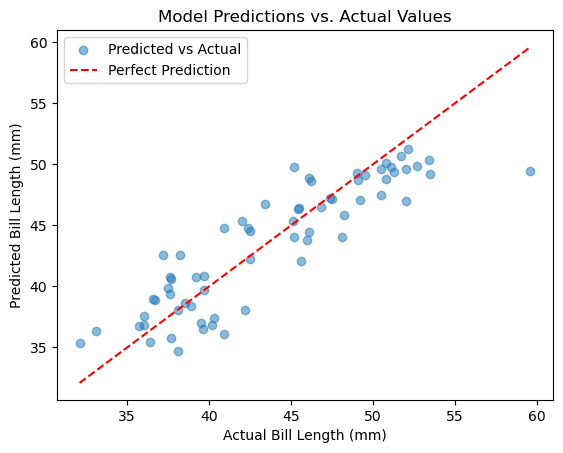

In [119]:
plt.scatter(y_test, y_pred, alpha=0.5, label="Predicted vs Actual")
plt.xlabel("Actual Bill Length (mm)")
plt.ylabel("Predicted Bill Length (mm)")
plt.title("Model Predictions vs. Actual Values")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
         color='red', linestyle='dashed', label="Perfect Prediction")  
plt.legend()
plt.show()

In [120]:
T = 20     # number of trials

# space to save relative errors
error_1 = np.zeros(T)   

for i in range(T):
    
    # compute errors for model 1
    mse1, rel_se1 = comput_test_error(X, y)
    error_1[i] = rel_se1
print(f'Average relative error of model 1 is {np.mean(error_1):.4f}')

Average relative error of model 1 is 0.0037


# Now some real work

# We will make model 2 and model 3 to predict species using some other data

*model 2
Will be using logisitic model in this part

In [126]:
url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/refs/heads/main/inst/extdata/penguins.csv'
df = pd.read_csv(url)


In [128]:
#notice the req:split your data before you clean
train_raw, test_raw = train_test_split(df, test_size=0.2)

In [130]:
#a function to clean code so we can reuse ..
def clean_data(raw_df):
    """
    clean
    Arg: dataframe
    Ret: cleaned dataframe
    """
    df = raw_df.copy()
    df.dropna(inplace = True)
    return df
# I have checked that there aren't too many NAN rows 
# Moreover the rows with NAN rows have multiple NAN in the columns
# hence Drop is OK
train_df = clean_data(train_raw)
test_df = clean_data(test_raw)

Now I want to visulize some of the data

In [133]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


* I want to use barchart to see the bill_length_mm	bill_depth_mm	flipper_length_mm	body_mass_g of different species/sex

* I involve sex here just to get some more info,might not be that important 

In [136]:
#body_length_mm
group_means = (
    df.groupby(['sex', 'species'])['body_mass_g'].mean().reset_index()
)
group_means.columns = ['sex', 'species', 'mean_body_mass']
print(group_means)

      sex    species  mean_body_mass
0  female     Adelie     3368.835616
1  female  Chinstrap     3527.205882
2  female     Gentoo     4679.741379
3    male     Adelie     4043.493151
4    male  Chinstrap     3938.970588
5    male     Gentoo     5484.836066


['Adelie-female', 'Chinstrap-female', 'Gentoo-female', 'Adelie-male', 'Chinstrap-male', 'Gentoo-male']


Text(0, 0.5, 'Mass_mean')

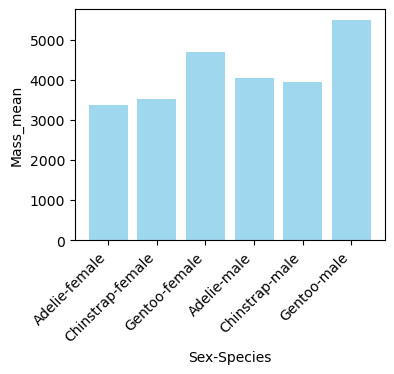

In [138]:
fig, ax = plt.subplots(figsize=(4,3))

plt.bar(range(6), group_means['mean_body_mass'], 
        color='skyblue', alpha=0.8)
#make the x_axis
x_tick = [f"{row['species']}-{row['sex']}" for i, 
          row in group_means.iterrows()]
print(x_tick)
plt.xlabel('Sex-Species')
ax.set_xticks(range(6))
ax.set_xticklabels(x_tick, rotation=45, ha='right')
#y
plt.ylabel('Mass_mean')

OK I think the difference is kind of trivial between Adelie and Chinstrap, I will do some analysis first before I plot in the following

In [141]:
# bill_length_mm	
group_means = (
    df.groupby(['sex', 'species'])['bill_length_mm'].mean().reset_index()
)
group_means.columns = ['sex', 'species', 'bill_length_mm']
print(group_means)

      sex    species  bill_length_mm
0  female     Adelie       37.257534
1  female  Chinstrap       46.573529
2  female     Gentoo       45.563793
3    male     Adelie       40.390411
4    male  Chinstrap       51.094118
5    male     Gentoo       49.473770


In [143]:
# bill_depth_mm
group_means2 = (
    df.groupby(['sex', 'species'])['bill_depth_mm'].mean().reset_index()
)
group_means2.columns = ['sex', 'species', 'bill_depth_mm']
print(group_means2)

      sex    species  bill_depth_mm
0  female     Adelie      17.621918
1  female  Chinstrap      17.588235
2  female     Gentoo      14.237931
3    male     Adelie      19.072603
4    male  Chinstrap      19.252941
5    male     Gentoo      15.718033


In [145]:
# flipper_length_mm
group_means3 = (
    df.groupby(['sex', 'species'])['flipper_length_mm']
    .mean().reset_index()
)
group_means3.columns = ['sex', 'species', 'flipper_length_mm']
print(group_means3)

      sex    species  flipper_length_mm
0  female     Adelie         187.794521
1  female  Chinstrap         191.735294
2  female     Gentoo         212.706897
3    male     Adelie         192.410959
4    male  Chinstrap         199.911765
5    male     Gentoo         221.540984


# Quantitative data decision
* I now realize that body mass doesn't differentiate between penguin 1 and 2, and bill_length doesn't differentiate between penguin 2 and 3, so shouldn't I use both together?
* So I have decied to use the two quantitative data are body mass and bill_length

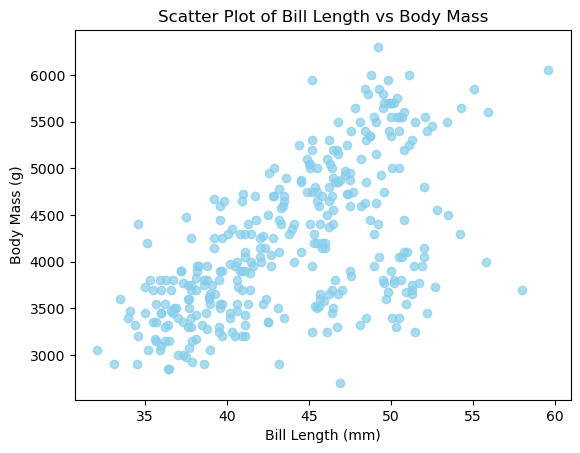

In [148]:
plt.scatter(df['bill_length_mm'], df['body_mass_g'], color='skyblue', 
            alpha=0.7)
plt.xlabel('Bill Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Scatter Plot of Bill Length vs Body Mass')
plt.show()

* as shown above these two data are not so repetitive

# now I need to decide either to use sex or island as qualitative

In [152]:
#sex
sex_count = (
    df.groupby(['species','sex']).size().reset_index(name='count')
)
print(sex_count)

     species     sex  count
0     Adelie  female     73
1     Adelie    male     73
2  Chinstrap  female     34
3  Chinstrap    male     34
4     Gentoo  female     58
5     Gentoo    male     61


In [154]:
# island
island_count = (
    df.groupby(['species','island']).size().reset_index(name='count')
)
print(island_count)

     species     island  count
0     Adelie     Biscoe     44
1     Adelie      Dream     56
2     Adelie  Torgersen     52
3  Chinstrap      Dream     68
4     Gentoo     Biscoe    124


# Obviously, by the chart aboce, we should definitely use Island
* sex give little info as it is almost 50/50
* we need some characteristic that allow us to judge with highr confidence (just like bayes idea in probability class)
* consider bayes thm the 50/50 multiplyer is not really useful
* I do not know how to type it down but below is the idea
* p(a|male) = p(male|a)*p(a)/p(male)
* where p(male) is some 0.5 and p(male|a) is also some 0.5 isn't that useless?
* p(a|Biscoe) = p(Biscoe|a)*(a)/p(Biscoe) will be way better as it will make a difference

# Through step 2, we chose the data to use after some trivial analyis by chart and visualization

* Remark other combination of quantitative like bill_length and bill_depth will also work
* same reason: one set distinguish peguin1,2 while the other set of data distinguish set 2,3

# Finally let's apply some models

# Model Logistic

In [160]:
# notice that I have both one_hot and label code function in the warm_up model 1

label(train_df,['island'])
label(train_df,['species'])
label(test_df,['island'])
label(test_df,['species'])

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
163,2,0,49.0,16.1,216.0,5550.0,male,2007
95,0,1,40.8,18.9,208.0,4300.0,male,2008
339,1,1,55.8,19.8,207.0,4000.0,male,2009
169,2,0,49.2,15.2,221.0,6300.0,male,2007
205,2,0,50.1,15.0,225.0,5000.0,male,2008
...,...,...,...,...,...,...,...,...
108,0,0,38.1,17.0,181.0,3175.0,female,2009
145,0,1,39.0,18.7,185.0,3650.0,male,2009
147,0,1,36.6,18.4,184.0,3475.0,female,2009
244,2,0,45.5,14.5,212.0,4750.0,female,2009


In [162]:
from sklearn.linear_model import LogisticRegression

# train test split
# remember that train_df, test_df is clean
X_train = train_df[['island', 'bill_length_mm', 'body_mass_g']]
y_train = train_df['species']

X_test = test_df[['island', 'bill_length_mm', 'body_mass_g']]
y_test = test_df['species']


model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy) 


Accuracy: 0.9850746268656716


# Cross Validation

In [166]:
from sklearn.model_selection import cross_val_score

from sklearn.metrics import confusion_matrix
C = [0.5,0.8,0.95,1,1.05,1.2,2,4,8,100]

acc = []

for c in C:
    clf =  LogisticRegression(C=c, solver='lbfgs', max_iter=5000) #copied this
    scores = cross_val_score(clf, X_train, y_train, cv=5)
    acc.append(np.mean(scores))
    
print(acc)

# present the result: make reproducible
acc = np.array(acc)
idx = np.argmax(acc)
print(f'The optimal C is {C[idx]}')

[0.9624039133473096, 0.9699510831586304, 0.9699510831586304, 0.9699510831586304, 0.9699510831586304, 0.9699510831586304, 0.9662473794549266, 0.9662473794549266, 0.9662473794549266, 0.9662473794549266]
The optimal C is 0.8


actually no significant diff between 0.95 and 1

In [45]:
print(confusion_matrix(y_test, y_pred))
print(" ")

[[33  0  0]
 [ 1 13  0]
 [ 2  0 19]]
 


In [46]:
def plot_decision_region_for_island(model, island_value, 
                                    X, resolution=0.01):
    
    # get the range of two continuous variables
    x_min = X['bill_length_mm'].min() - 1
    x_max = X['bill_length_mm'].max() + 1
    y_min = X['body_mass_g'].min() - 1
    y_max = X['body_mass_g'].max() + 1

    # create the grid
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # create DataFrame for prediction
    grid_df = pd.DataFrame({
        'island': [island_value] * xx.size,
        'bill_length_mm': xx.flatten().tolist(),
        'body_mass_g': yy.flatten().tolist()
    })
    
    Z = model.predict(grid_df).reshape(xx.shape)
    
    # create figure
    plt.imshow(Z, extent=(x_min, x_max, y_min, y_max), origin='lower', 
               alpha=0.3, cmap=plt.cm.Paired, aspect='auto')
    plt.xlabel("Bill Length")
    plt.ylabel("Body Mass")
    
    idx = X['island'] == island_value
    plt.scatter(X.loc[idx, 'bill_length_mm'], 
                X.loc[idx, 'body_mass_g'], 
                c='black', edgecolor='white', s=50, 
                label='Training points')

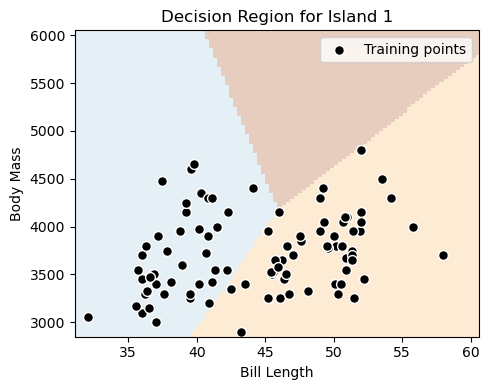

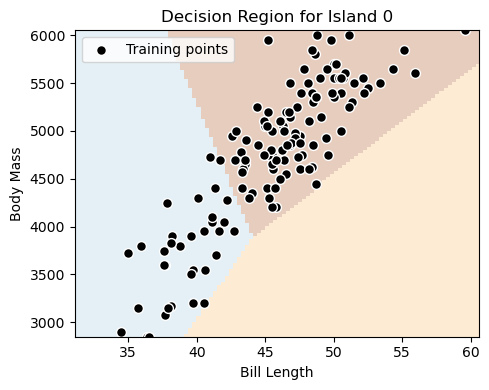

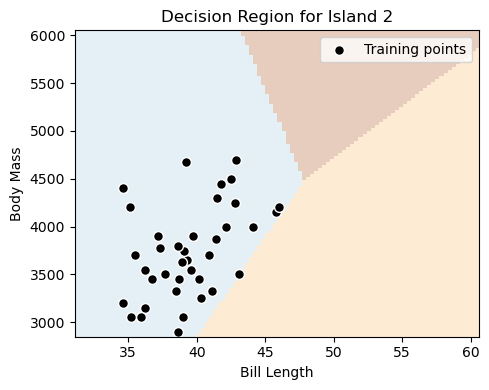

In [47]:
# visulization
for island in X_train['island'].unique():
    plt.figure(figsize=(5,4))
    plot_decision_region_for_island(model, island, X_train, 
                                    resolution=0.01)
    plt.title(f"Decision Region for Island {island}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Model Support Vector Machine

* use linear

In [49]:
# we will use exactly the same x_train, y_train, x_test, y_test
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

# train test split
# remember that train_df, test_df is clean
X_train = train_df[['island', 'bill_length_mm', 'body_mass_g']]
y_train = train_df['species']

X_test = test_df[['island', 'bill_length_mm', 'body_mass_g']]
y_test = test_df['species']
#normaliza to (0,1)
for col in ['bill_length_mm', 'body_mass_g']:
    mean_val = X_train[col].mean()
    std_val = X_train[col].std()
    X_train.loc[:, col] = (X_train[col] - mean_val) / std_val
    X_test.loc[:, col] = (X_test[col] - mean_val) / std_val



model_2 = SVC(C=8,kernel='poly',degree=2,coef0=1).fit(X_train,y_train) 
#coef0 = 1 happen to be good after some tries
y_pred2 = model_2.predict(X_test)
acc2 = sum(y_pred2.reshape(y_test.shape)==y_test)/y_test.size
print('Test accuracy of support vector machine (polynomial kernel) is ', 
      acc2 )


#just for fun

clf_2 = LinearSVC(C=20, loss="hinge", max_iter=5000).fit(X_train, y_train)
#model2 = LinearSVC(C=20,loss="hinge").fit(X_train,y_train)
y_pred1 = clf_2.predict(X_test)
acc1 = sum(y_pred1.reshape(y_test.shape)==y_test)/y_test.size
print('Test accuracy of linear support vector machine is ', acc1 )


clf_3 = SVC(C=20, kernel='rbf', gamma=1, 
            max_iter=10000).fit(X_train, y_train)
y_pred3 = clf_3.predict(X_test)
acc3 = sum(y_pred3.reshape(y_test.shape)==y_test)/y_test.size
print('Test accuracy of support vector machine (rbf kernel) is ', acc3 )

Test accuracy of support vector machine (polynomial kernel) is  0.9558823529411765
Test accuracy of linear support vector machine is  0.9411764705882353
Test accuracy of support vector machine (rbf kernel) is  0.9558823529411765


# Cross Validation

In [51]:
from sklearn.model_selection import cross_val_score

from sklearn.metrics import confusion_matrix

C = [0.5,1,2,4,8,10,15,100]

acc = []

for c in C:
    clf = SVC(kernel='poly', C=c, degree=2, coef0=1)
    scores = cross_val_score(clf, X_train, y_train, cv=5)
    acc.append(np.mean(scores))
    
print(acc)

# present the result: make reproducible
acc = np.array(acc)
idx = np.argmax(acc)
print(f'The optimal C is {C[idx]}')

[0.9584905660377359, 0.9735849056603774, 0.9735849056603774, 0.969811320754717, 0.9735849056603773, 0.9773584905660376, 0.9773584905660376, 0.9735849056603773]
The optimal C is 10


In [52]:
#confusion matrix
print(confusion_matrix(y_test, y_pred2))
print(" ")

[[33  0  0]
 [ 1 13  0]
 [ 2  0 19]]
 


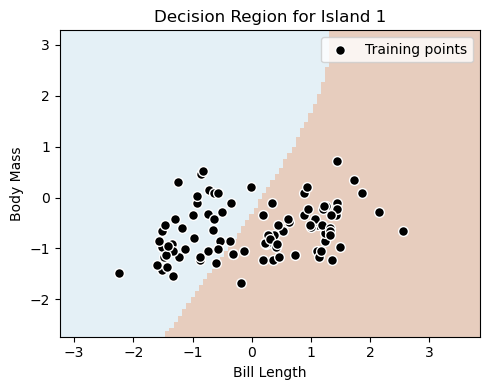

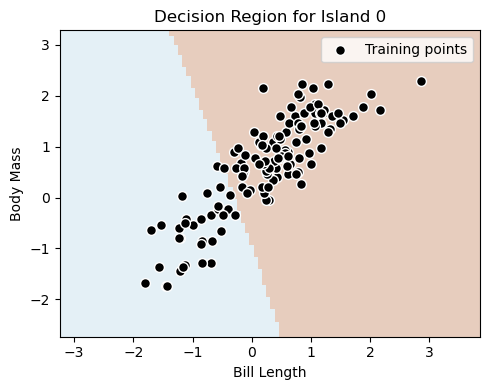

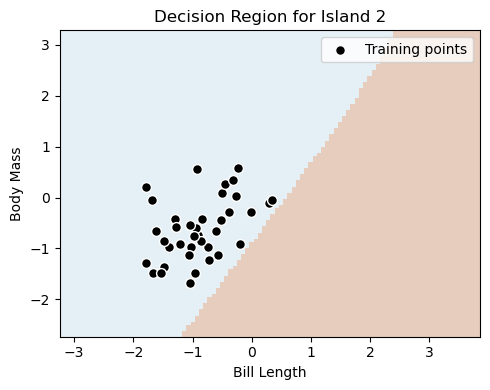

In [53]:
#visulization
for island in X_train['island'].unique():
    plt.figure(figsize=(5,4))
    plot_decision_region_for_island(model_2, island, X_train, 
                                    resolution=0.01)
    plt.title(f"Decision Region for Island {island}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Discussion

In this experiment, we compared the classification performance of Logistic Regression, SVM (Polynomial Kernel & RBF Kernel) and observed significant differences in their behavior under different scenarios.

1. Logistic Regression:
Logistic regression is inherently linear, meaning its decision boundary is always a straight line. It performs well when dealing with simple, linearly separable data, but when the data is more curved or nonlinear, it struggles to classify points correctly, leading to misclassifications.

2. Polynomial Kernel SVM:
Compared to logistic regression, the polynomial kernel SVM can generate nonlinear decision boundaries, improving classification performance. However, if the degree of the polynomial is not chosen properly, the decision boundary might either be too simple or too complex, affecting classification results.
During our experiment, we tried adjusting the SVM parameters and found that when C=10 and coef=1, the model performed better, indicating that selecting the right parameters helps the model create a more effective decision boundary.

3. RBF Kernel SVM:
The RBF kernel SVM provides a more flexible decision boundary, adapting to the data distribution more naturally. From our results, it outperformed both logistic regression and polynomial SVM. However, the parameters are very important if they are not well-tuned, the model may either overfit or underfit.

4. Conclusion:
The decision region plots clearly show that different models produce different decision boundary shapes, leading to varying classification performance. Overall, logistic regression is suitable for linearly separable data, while SVM is more effective for complex cases. However, parameter tuning is essential, especially for SVM models. Finding the right values for C and gamma is key to balancing accuracy and generalization. For example, in this experiment, after adjusting the parameters (C=8, coef=2), the model's performance significantly improved, highlighting the importance of proper parameter selection.


In [55]:
clf = SVC(C=10, kernel='rbf', gamma=1, 
          probability=True).fit(X_train, y_train)
prob = clf.predict_proba(X_test)
print(prob)

[[1.68749540e-02 4.80113750e-03 9.78323908e-01]
 [8.64628475e-01 1.09838228e-02 1.24387702e-01]
 [9.97211028e-01 1.04081970e-03 1.74815220e-03]
 [9.95563140e-01 6.05135993e-05 4.37634637e-03]
 [9.76265767e-01 1.02280979e-02 1.35061354e-02]
 [9.02928231e-01 7.62832028e-02 2.07885658e-02]
 [3.66815072e-02 8.68078703e-03 9.54637706e-01]
 [9.83830714e-01 1.14720374e-02 4.69724831e-03]
 [5.19050456e-02 5.54668889e-03 9.42548266e-01]
 [9.04002287e-01 6.45499031e-02 3.14478103e-02]
 [9.38007802e-01 2.22349449e-02 3.97572536e-02]
 [3.36963756e-02 8.42968579e-03 9.57873939e-01]
 [9.93516844e-01 2.25275407e-03 4.23040182e-03]
 [2.56346433e-02 9.58705432e-01 1.56599247e-02]
 [4.61000862e-03 9.83402776e-01 1.19872156e-02]
 [2.09498847e-02 9.06339368e-01 7.27107472e-02]
 [5.81744735e-03 9.81960829e-01 1.22217241e-02]
 [1.99209720e-02 5.16077223e-03 9.74918256e-01]
 [9.70124305e-01 5.77876471e-03 2.40969300e-02]
 [3.99018318e-02 1.16115242e-02 9.48486644e-01]
 [9.59218944e-01 8.80488575e-03 3.197617

In [56]:
def thresholdcheck(p,prob1):
    """
    p a probablity (0,1)
    species num 0,1,2
    prob: prob
    """
    y_pred = []
    species_col = prob1[:,0]
    for i in range(len(species_col)):
        if species_col[i]>p:
            y_pred.append(0)
        elif prob1[i,1] < prob1[i,2]:
            y_pred.append(2)
        else:
            y_pred.append(1)
    y_pred = np.array(y_pred)
    acc = sum(y_pred == y_test)/y_test.size
    print(acc)



In [57]:
thresholdcheck(0.3,prob)

0.9558823529411765


In [58]:
thresholdcheck(0.5,prob)

0.9558823529411765


In [59]:
thresholdcheck(0.8,prob)

0.9411764705882353
